In [1]:
import numpy as np
import matplotlib.pyplot as plt

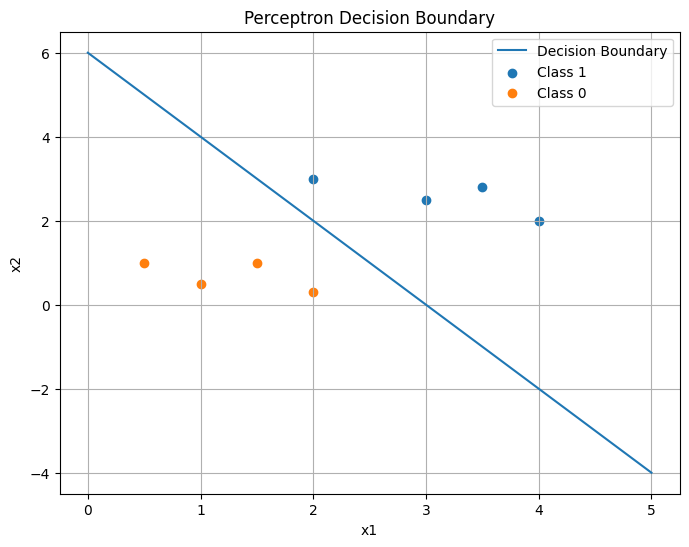

In [2]:

# Create x1 values
x1 = np.linspace(0, 5, 100)

# Perceptron parameters
w1 = 2
w2 = 1
b = -6

# Decision boundary:
# w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b) / w2

x2 = -(w1 * x1 + b) / w2

plt.figure(figsize=(8, 6))

# Plot decision boundary
plt.plot(x1, x2, label="Decision Boundary")

# Class 1 points
class1_x = [2, 3, 3.5, 4]
class1_y = [3, 2.5, 2.8, 2]

# Class 0 points
class0_x = [0.5, 1, 1.5, 2]
class0_y = [1, 0.5, 1, 0.3]

plt.scatter(class1_x, class1_y, label="Class 1")
plt.scatter(class0_x, class0_y, label="Class 0")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")

plt.legend()
plt.grid(True)
plt.show()

In [4]:


class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def step_function(self, z):
        return 1 if z >= 0 else 0

    def fit(self, X, y):

        # Start weights with zeros
        self.weights = np.zeros(X.shape[1])

        # Start bias with zero
        self.bias = 0

        # Training
        for epoch in range(self.epochs):

            for i in range(len(X)):

                # Weighted sum
                z = np.dot(X[i], self.weights) + self.bias

                # Prediction
                y_pred = self.step_function(z)

                # Error
                error = y[i] - y_pred

                # Update weights
                self.weights += self.learning_rate * error * X[i]

                # Update bias
                self.bias += self.learning_rate * error

    def predict(self, X):

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            prediction = self.step_function(z)

            predictions.append(prediction)

        return np.array(predictions)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Training data
# -----------------------------

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [5, 5],
    [6, 5],
    [5, 6]
])

# Class labels
y = np.array([0, 0, 0, 1, 1, 1])


# -----------------------------
# Perceptron parameters
# -----------------------------

learning_rate = 0.1
epochs = 10

# Start with zero weights
weights = np.zeros(2)

# Start with zero bias
bias = 0


# Store errors for visualization
errors_per_epoch = []


# -----------------------------
# Training
# -----------------------------

for epoch in range(epochs):

    errors = 0

    for i in range(len(X)):

        # Calculate weighted sum
        z = np.dot(X[i], weights) + bias

        # Step activation
        prediction = 1 if z >= 0 else 0

        # Calculate error
        error = y[i] - prediction

        # Update weights
        weights = weights + learning_rate * error * X[i]

        # Update bias
        bias = bias + learning_rate * error

        # Count mistake
        if error != 0:
            errors += 1

    errors_per_epoch.append(errors)

    print(
        f"Epoch {epoch + 1}: "
        f"Errors = {errors}, "
        f"Weights = {weights}, "
        f"Bias = {bias:.2f}"
    )

Epoch 1: Errors = 2, Weights = [0.4 0.4], Bias = 0.00
Epoch 2: Errors = 4, Weights = [0.5 0.5], Bias = -0.20
Epoch 3: Errors = 3, Weights = [0.1 0.1], Bias = -0.50
Epoch 4: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 5: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 6: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 7: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 8: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 9: Errors = 0, Weights = [0.1 0.1], Bias = -0.50
Epoch 10: Errors = 0, Weights = [0.1 0.1], Bias = -0.50


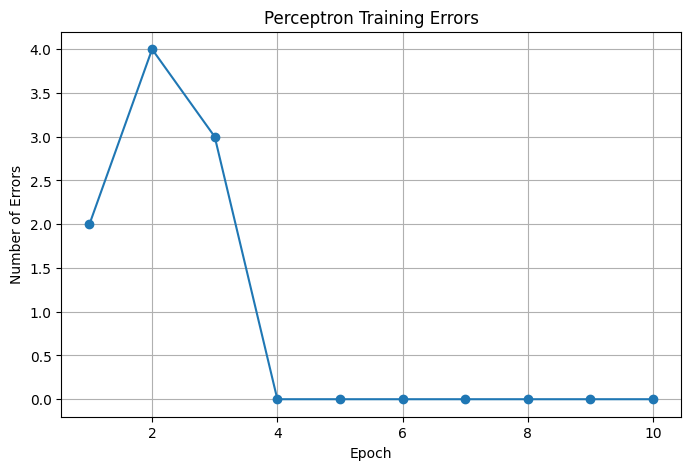

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    errors_per_epoch,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Number of Errors")
plt.title("Perceptron Training Errors")
plt.grid(True)

plt.show()

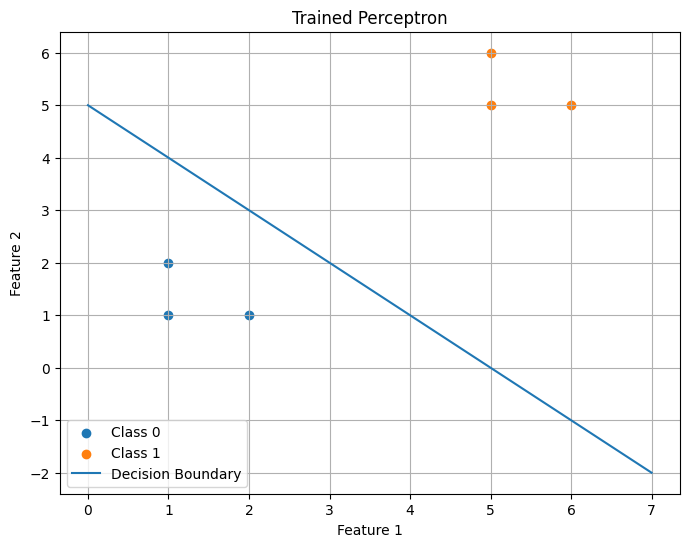

In [7]:
# decision boundary
plt.figure(figsize=(8, 6))

# Plot class 0
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

# Plot class 1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

# Decision boundary:
# w1*x1 + w2*x2 + b = 0
x1_values = np.linspace(0, 7, 100)

x2_values = (
    -(weights[0] * x1_values + bias)
    / weights[1]
)

plt.plot(
    x1_values,
    x2_values,
    label="Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Trained Perceptron")
plt.legend()
plt.grid(True)

plt.show()

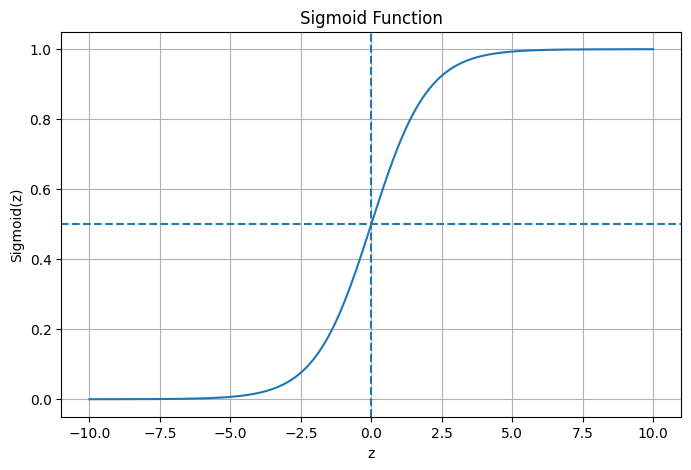

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

y = sigmoid(z)

plt.figure(figsize=(8, 5))

plt.plot(z, y)

plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)

plt.show()

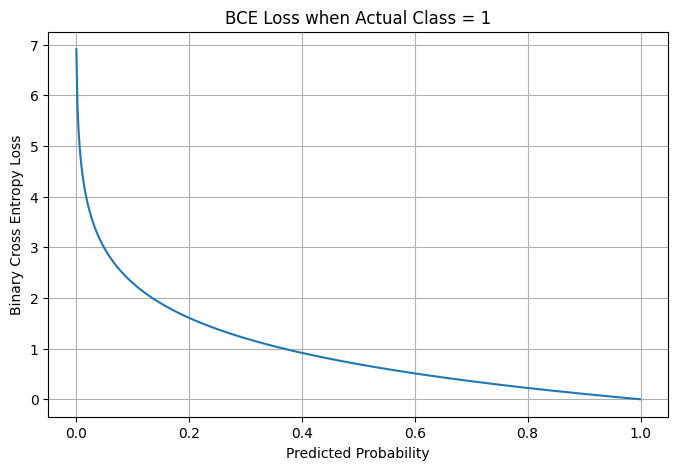

In [9]:
# bonary cross entropy
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.001, 0.999, 500)

loss_when_y1 = -np.log(p)

plt.figure(figsize=(8, 5))

plt.plot(p, loss_when_y1)

plt.xlabel("Predicted Probability")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("BCE Loss when Actual Class = 1")

plt.grid(True)
plt.show()

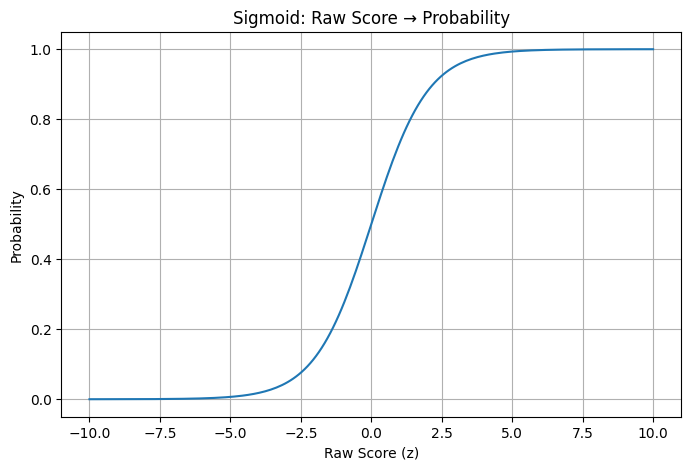

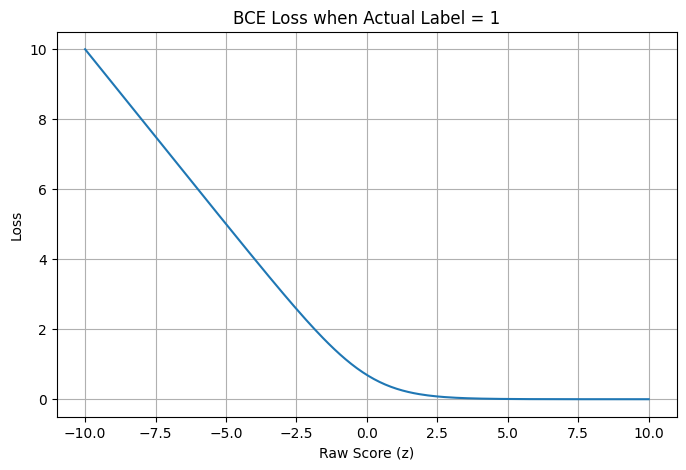

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Raw scores
z = np.linspace(-10, 10, 200)

# Sigmoid
probability = 1 / (1 + np.exp(-z))

# Binary cross entropy
# Assume actual label y = 1
loss = -np.log(probability)

plt.figure(figsize=(8, 5))

plt.plot(z, probability)

plt.xlabel("Raw Score (z)")
plt.ylabel("Probability")
plt.title("Sigmoid: Raw Score → Probability")

plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(z, loss)

plt.xlabel("Raw Score (z)")
plt.ylabel("Loss")
plt.title("BCE Loss when Actual Label = 1")

plt.grid(True)
plt.show()